# Spline interpolation with Green's functions - 3D

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import numpy as np
import functions as fc
from gravmag.models import rectangular_prism as rp
from gravmag import data_structures, utils, check
from gravmag import plot_functions as plf

In [2]:
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

In [3]:
# Python package noise (https://github.com/caseman/noise) for generating Perlin noise.
# Such noise is usefull to simulate topography.
import noise

In [4]:
import gc

In [5]:
def model_cut(model, pmin, pmax):
    check.are_rectangular_prisms(model)
    check.is_integer(x=pmin, positive=True, include_zero=True)
    check.is_integer(x=pmax, positive=True, include_zero=True)
    if pmin >= pmax:
        raise ValueError('pmin must be greater than pmax')
    nprisms = model['x1'].size
    if pmin >= nprisms:
        raise ValueError('pmin must be smaller than num. of model prisms')
    if pmax >= nprisms:
        raise ValueError('pmax must be smaller than num. of model prisms')
    selected_model = dict()
    for element in model.keys():
        selected_model[element] = model[element][pmin:pmax+1]
    return selected_model

### Create a model

In [6]:
# Set the model area
# minimum x, maximum x, minimum y and maximum y
model_area = [-5100, 4900, -3800, 6200]

In [7]:
# dictionary to store the model
model = dict()

#### Main model

In [8]:
# Create a model formed by a five prisms
Nmain = 5
prisms_main = np.array([[-500, 500, 0, 2000, 10, 1010],
                        [-1500, -500, 1000, 3000, 100, 1200],
                        [1000, 3000, 2000, 2500, 90, 1500],
                        [-4000, -1000, -3000, 1000, 100, 1400],
                        [-3000, 1000, -2000, 4000, 1000, 2000]])

In [9]:
# generate random total-magnetization intensity (A / m) values
rng = np.random.default_rng(126543786908888123)
mag_intensities_main = rng.uniform(low=2, high=3, size=Nmain)
#mag_intensities_main = rng.uniform(low=12, high=13, size=Nmain)

In [10]:
# set constant total-magnetization inclination and declination (°) values
inc_sources = -24.2
dec_sources = -45.8

mag_incs_main = np.zeros(Nmain) + inc_sources
mag_decs_main = np.zeros(Nmain) + dec_sources

#### Geological noise

In [11]:
# center of Ns sources randomly distributed in the simulated area
Ngn = 300

xgn = model_area[0] + (model_area[1] - model_area[0])*np.random.rand(Ngn)
ygn = model_area[2] + (model_area[3] - model_area[2])*np.random.rand(Ngn)
zgn_top = 100.*np.random.rand(Ngn)

# sizes 
Lgn = 100. + 200*np.random.rand(Ngn)

# total magnetizations
mag_intensities_gn = 3*np.random.rand(Ngn)
mag_incs_gn = np.zeros(Ngn) + inc_sources
mag_decs_gn = np.zeros(Ngn) + dec_sources

# create the sources
prisms_gn = np.zeros((Ngn, 6))
prisms_gn[:,0] = xgn - 0.5*Lgn
prisms_gn[:,1] = xgn + 0.5*Lgn
prisms_gn[:,2] = ygn - 0.5*Lgn
prisms_gn[:,3] = ygn + 0.5*Lgn
prisms_gn[:,4] = 0.
prisms_gn[:,5] = zgn_top + Lgn

In [12]:
prisms = np.vstack([prisms_main, prisms_gn])
mag_intensities = np.hstack([mag_intensities_main, mag_intensities_gn])
mag_incs = np.hstack([mag_incs_main, mag_incs_gn])
mag_decs = np.hstack([mag_decs_main, mag_decs_gn])

In [13]:
prisms_dict = {
    'x1' : prisms[:,0],
    'x2' : prisms[:,1],
    'y1' : prisms[:,2],
    'y2' : prisms[:,3],
    'z1' : prisms[:,4],
    'z2' : prisms[:,5]
}

In [14]:
prisms_long_wavelength_dict = {
    'x1' : prisms_main[4:,0],
    'x2' : prisms_main[4:,1],
    'y1' : prisms_main[4:,2],
    'y2' : prisms_main[4:,3],
    'z1' : prisms_main[4:,4],
    'z2' : prisms_main[4:,5]
}

prisms_mid_wavelength_dict = {
    'x1' : prisms_main[:4,0],
    'x2' : prisms_main[:4,1],
    'y1' : prisms_main[:4,2],
    'y2' : prisms_main[:4,3],
    'z1' : prisms_main[:4,4],
    'z2' : prisms_main[:4,5]
}

In [15]:
model['prisms'] = prisms_dict
model['mag-intensities'] = mag_intensities
model['mag-inclinations'] = mag_incs
model['mag-declinations'] = mag_decs

In [16]:
del (
    prisms_dict, prisms_long_wavelength_dict, prisms_mid_wavelength_dict, 
    mag_intensities, mag_incs, mag_decs, prisms_gn, Lgn, prisms_main, mag_intensities_main,
    mag_incs_main, mag_decs_main, xgn, ygn, zgn_top)
gc.collect()

0

In [17]:
print(f"Model top: {np.min(model['prisms']['z1']):>7.2f} m")

Model top:    0.00 m


In [18]:
# model properties
print("(xmin, xmax) = ({:.3f}, {:.3f}) m".format(model['prisms']['x1'].min(), model['prisms']['x2'].max()))
print("(ymin, ymax) = ({:.3f}, {:.3f}) m".format(model['prisms']['y1'].min(), model['prisms']['y2'].max()))
print("(top min, top max) = ({:.3f}, {:.3f}) m".format(model['prisms']['z1'].min(), model['prisms']['z1'].max()))
print("(bottom min, bottom max) = ({:.3f}, {:.3f}) m".format(model['prisms']['z2'].min(), model['prisms']['z2'].max()))
print("number of prisms: {}".format(model['prisms']['x1'].size))

(xmin, xmax) = (-5150.680, 4940.776) m
(ymin, ymax) = (-3897.063, 6297.674) m
(top min, top max) = (0.000, 1000.000) m
(bottom min, bottom max) = (107.441, 2000.000) m
number of prisms: 305


In [19]:
# Cartesian components of the total magnetization
h_hat = utils.unit_vector(inc=model['mag-inclinations'][0], dec=model['mag-declinations'][0])

In [20]:
# compute a normalized horizontal projection of h_hat to plot
h_hat_horizontal = h_hat[:2]/np.linalg.norm(h_hat[:2])

### Synthetic terrain model

In [21]:
terrain = dict()

In [22]:
# number of points along x and y
terrain['shape'] = (500, 500)

# minimum x, maximum x, minimum y and maximum y
terrain['area'] = [-5000, 5000, -4000, 6000]

In [23]:
# number of points along x and y
print('n. terrain data = {}'.format(terrain['shape'][0]*terrain['shape'][1]))

# terrain grid spacing
terrain_dx, terrain_dy = data_structures.grid_xy_spacing(area=terrain['area'], shape=terrain['shape'])
print('dx = {:.3f} m | dy = {:.3f} m'.format(terrain_dx, terrain_dy))

n. terrain data = 250000
dx = 20.040 m | dy = 20.040 m


In [24]:
# create a variable to store the data surface
z = np.empty(terrain['shape'])

#### Generate a synthetic random surfaces with the Python package [`noise`](https://pypi.org/project/noise/),
# by following the example presented at [Jack McKew's Blog](https://jackmckew.dev/3d-terrain-in-python.html)

# generate the data surface
for i in range(terrain['shape'][0]):
    for j in range(terrain['shape'][1]):
        z[i][j] = 150*noise.pnoise2(
            i/200, 
            j/300, 
            octaves=23, 
            persistence=0.2,
            lacunarity=8, 
            repeatx=3, 
            repeaty=2, 
            base=0
        )

z -= 110.0

In [25]:
y, x = np.meshgrid(
    np.linspace(terrain['area'][2], terrain['area'][3], terrain['shape'][1]),
    np.linspace(terrain['area'][0], terrain['area'][1], terrain['shape'][0]),
)

terrain['coordinates'] = {
    'x': x,
    'y': y,
    'z': z
}

In [26]:
print(f"Terrain ranges: [{np.min(terrain['coordinates']['z']):>7.2f}, {np.max(terrain['coordinates']['z']):>7.2f}] m")

Terrain ranges: [-200.64,   -0.31] m


In [27]:
data_points = dict()

# index_interval_x = 1
# index_interval_y = 20
index_interval_x = 10
index_interval_y = 10

# number of points along x and y
data_points['shape'] = (x[::index_interval_x,0].size, y[0,::index_interval_y].size)

# minimum x, maximum x, minimum y and maximum y
data_points['area'] = [
    float(x[::index_interval_x,0].min()), 
    float(x[::index_interval_x,0].max()), 
    float(y[0,::index_interval_y].min()), 
    float(y[0,::index_interval_y].max())
]

In [28]:
# number of points along x and y
print('n. data = {}'.format(data_points['shape'][0]*data_points['shape'][1]))

# grid spacing
data_dx, data_dy = data_structures.grid_xy_spacing(area=data_points['area'], shape=data_points['shape'])
print('dx = {:.3f} m | dy = {:.3f} m'.format(data_dx, data_dy))

n. data = 2500
dx = 200.401 m | dy = 200.401 m


In [29]:
data_points['coordinates'] = {
    'x': x[::index_interval_x,::index_interval_y].ravel(),
    'y': y[::index_interval_x,::index_interval_y].ravel(),
    'z': z[::index_interval_x,::index_interval_y].ravel()
}

In [30]:
del x, y, z
gc.collect()

0

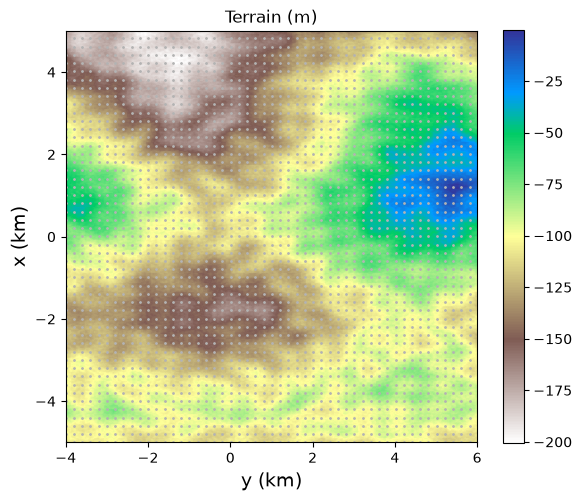

In [31]:
plt.close('all')
plt.figure(figsize=(6,5))

plt.title("Terrain (m)")
plt.axis('scaled')
plt.pcolor(
    terrain['coordinates']['y']*0.001, 
    terrain['coordinates']['x']*0.001, 
    terrain['coordinates']['z'], 
    cmap='terrain_r'
)
plt.colorbar()
plt.plot(
    0.001*data_points['coordinates']['y'], 
    0.001*data_points['coordinates']['x'], 
    lw=0, marker='.', c=3*(0.7,), ms=2
)
plt.ylim(0.001*terrain['area'][0], 0.001*terrain['area'][1])
plt.xlim(0.001*terrain['area'][2], 0.001*terrain['area'][3])
plt.xlabel('y (km)', fontsize=14)
plt.ylabel('x (km)', fontsize=14)

plt.tight_layout()

plt.show()

### Main field

In [32]:
main_field = dict()

In [33]:
# grid orientation
main_field['grid_orientation'] = 'xy'

# horizontal coordinates of the center
xc = (data_points['coordinates']['x'][0] + data_points['coordinates']['x'][-1]) / 2
yc = (data_points['coordinates']['y'][0] + data_points['coordinates']['y'][-1]) / 2

# inclination (degrees)
main_field['I'] = (
    -33 
    -1e-4*(data_points['coordinates']['x']-xc) 
    +3e-4*(data_points['coordinates']['y']-yc) 
    +1e-8*(data_points['coordinates']['x']-xc)*(data_points['coordinates']['x']-xc) 
    +1e-8*(data_points['coordinates']['y']-yc)*(data_points['coordinates']['y']-yc)
)

# declination (degrees)
main_field['D'] = (
    45 
    +6e-5*(data_points['coordinates']['x']-xc) 
    +1e-4*(data_points['coordinates']['y']-yc) 
    +3e-9*(data_points['coordinates']['x']-xc)*(data_points['coordinates']['x']-xc) 
    +4e-9*(data_points['coordinates']['y']-yc)*(data_points['coordinates']['y']-yc)
)

# intensity (nT)
main_field['F'] = (
    23400 
    +3e-4*(data_points['coordinates']['x']-xc) 
    +5e-4*(data_points['coordinates']['y']-yc) 
    +0*(data_points['coordinates']['x']-xc)*(data_points['coordinates']['x']-xc) 
    +0*(data_points['coordinates']['y']-yc)*(data_points['coordinates']['y']-yc)
)

# Cartesian components of the main field
cosI = np.cos(np.deg2rad(main_field['I']))
sinI = np.sin(np.deg2rad(main_field['I']))
cosD = np.cos(np.deg2rad(main_field['D']))
sinD = np.sin(np.deg2rad(main_field['D']))
main_field['x'] = main_field['F']*cosI*cosD
main_field['y'] = main_field['F']*cosI*sinD
main_field['z'] = main_field['F']*sinI

In [34]:
del cosI, sinI, cosD, sinD
gc.collect()

255461

In [35]:
# Compute the average main field
mean_I = np.mean(main_field['I'])
mean_D = np.mean(main_field['D'])
cos_mean_I = np.cos(np.deg2rad(mean_I))
sin_mean_I = np.sin(np.deg2rad(mean_I))
cos_mean_D = np.cos(np.deg2rad(mean_D))
sin_mean_D = np.sin(np.deg2rad(mean_D))
Fx_hat = cos_mean_I*cos_mean_D
Fy_hat = cos_mean_I*sin_mean_D
Fz_hat = sin_mean_I
F_hat = np.array([Fx_hat, Fy_hat, Fz_hat])

In [36]:
# compute a normalized horizontal projection of F_hat to plot
F_hat_horizontal = F_hat[:2]/np.linalg.norm(F_hat[:2])

In [37]:
titles = [
    'I', 'D', 'F', 
    'Fx', 'Fy', 'Fz'
]
units = [
    'degree', 'degree', 'nT', 
    'nT', 'nT', 'nT'
]
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

In [38]:
fields = ['I', 'D', 'F', 'x', 'y', 'z']

In [39]:
mosaic_elements = ['a', 'b', 'c', 'd', 'e', 'f']

In [40]:
color = 3*(0.4,)

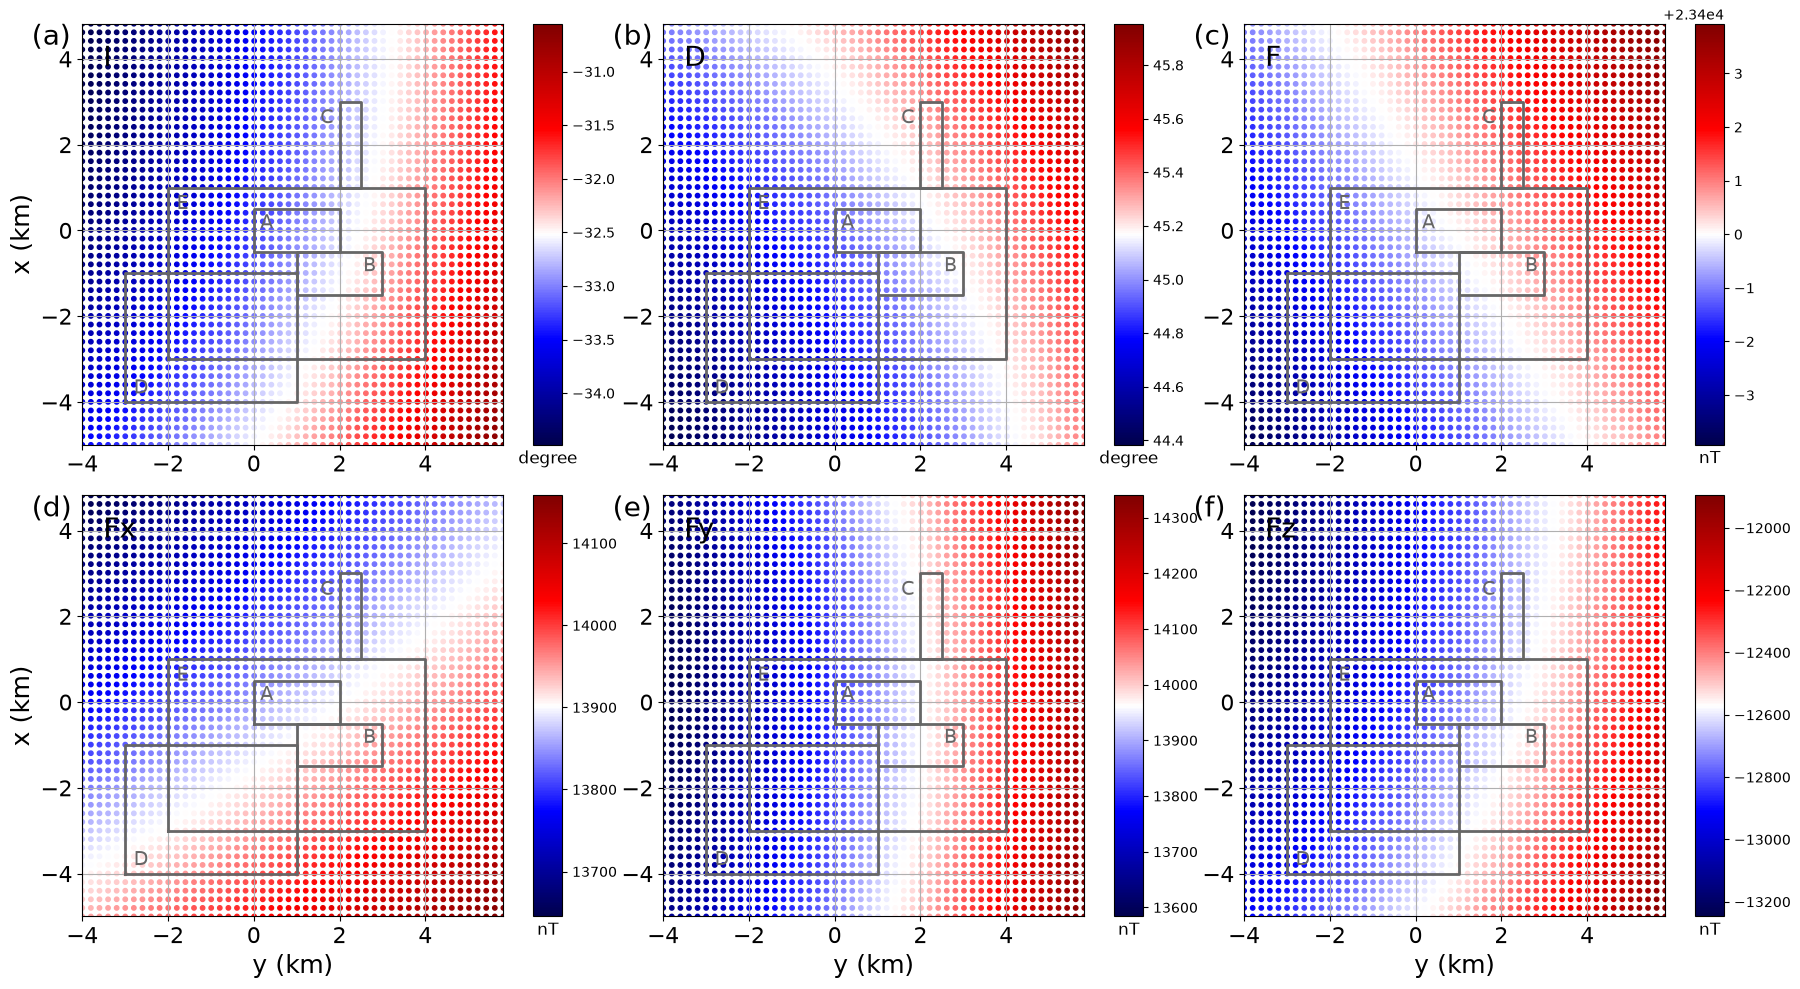

In [41]:
fig = plt.figure(layout= 'tight', figsize=(18,10))
mosaic = fig.subplot_mosaic('''
                            abc
                            def
                            ''')
# tensor components
for (element, field, title, label, unit) in zip(
    mosaic_elements, fields, titles, labels, units
):
    ax = mosaic[element]
    ax.axis('scaled')
    im = ax.scatter(
        x = data_points['coordinates']['y']*0.001, 
        y = data_points['coordinates']['x']*0.001, 
        s=10, 
        c = main_field[field],
        cmap='seismic', vmin=np.min(main_field[field]), vmax=np.max(main_field[field])
    )
    ax_divider = make_axes_locatable(ax)
    cax = ax_divider.append_axes("right", size="7%", pad="7%")
    cb = fig.colorbar(im, cax=cax, orientation='vertical')
    cb.ax.tick_params(labelsize=10, top=False, bottom=True, labeltop=False, labelbottom=True)
    cb.ax.set_xlabel(unit, fontsize=12, loc='center')
    ax.set_ylim(0.001*data_points['area'][0], 0.001*data_points['area'][1])
    ax.set_xlim(0.001*data_points['area'][2], 0.001*data_points['area'][3])
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid()
    ax.annotate(label, xy=(-0.12, 0.95), xycoords='axes fraction', fontsize=20)
    ax.annotate(title, xy=(0.05, 0.90), xycoords='axes fraction', fontsize=20)
    plf.model_boundaries(
        ax,
        model=model_cut(model['prisms'], pmin=0, pmax=4),
        color=color,
        style='-',
        width='2'
    )
    ax.annotate(text='A', xy=(0.15, 0.05), fontsize=14, color=color)
    ax.annotate(text='B', xy=(2.55, -0.95), fontsize=14, color=color)
    ax.annotate(text='C', xy=(1.55, 2.50), fontsize=14, color=color)
    ax.annotate(text='D', xy=(-2.80, -3.80), fontsize=14, color=color)
    ax.annotate(text='E', xy=(-1.80, 0.50), fontsize=14, color=color)

for element in ['a','d']:
    mosaic[element].set_ylabel('x (km)', fontsize=18)
for element in ['d','e', 'f']:
    mosaic[element].set_xlabel('y (km)', fontsize=18)
    
plt.show()

### Synthetic crustal data

In [42]:
crustal_field = dict()

#### Noise-free magnetic induction components  (in nT)

In [43]:
# compute the Cartesian components of magnetization
mx, my, mz = utils.magnetization_components(
    np.vstack([model['mag-intensities'], model['mag-inclinations'], model['mag-declinations']]).T
)

In [44]:
# Compute the Cartesian components
for component in ['x', 'y', 'z']:
    crustal_field[component] = rp.mag(
          coordinates=data_points['coordinates'], 
          prisms=model['prisms'], 
          mx = mx, 
          my = my, 
          mz = mz, 
          field=component
    )

In [45]:
del mx, my, mz
gc.collect()

56

In [46]:
# amplitude of anomalous magnetic field
crustal_field['b'] = np.sqrt(crustal_field['x']**2 + crustal_field['y']**2 + crustal_field['z']**2)

# Compute the approximated total-field anomaly (Blakely, 1996, p. 179)
crustal_field['atfa'] = F_hat[0]*crustal_field['x'] + F_hat[1]*crustal_field['y'] + F_hat[2]*crustal_field['z']

# Total-field anomaly
crustal_field['tfa'] = np.sqrt(
    (main_field['x'] + crustal_field['x'])**2 +
    (main_field['y'] + crustal_field['y'])**2 +
    (main_field['z'] + crustal_field['z'])**2
) - main_field['F']

In [47]:
main_field['F'].shape

(2500,)

In [48]:
crustal_field.keys()

dict_keys(['x', 'y', 'z', 'b', 'atfa', 'tfa'])

In [49]:
print("Average values of")
for field in crustal_field.keys():
    print(f"{field:>6s}: {crustal_field[field].shape}")

Average values of
     x: (2500,)
     y: (2500,)
     z: (2500,)
     b: (2500,)
  atfa: (2500,)
   tfa: (2500,)


### Plot the synthetic data with Matplotlib

In [50]:
titles = ['bx (nT)', 'by (nT)', 'bz (nT)', 'b (nT)', 'tfa (nT)', 'atfa (nT)']
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

In [51]:
ranges = []
for field in crustal_field.keys():
    ranges.append(0.9*np.max(np.abs(crustal_field[field])))

In [52]:
mosaic_elements = ['a', 'b', 'c', 'd', 'e', 'f']

In [53]:
color = 3*(0.4,)

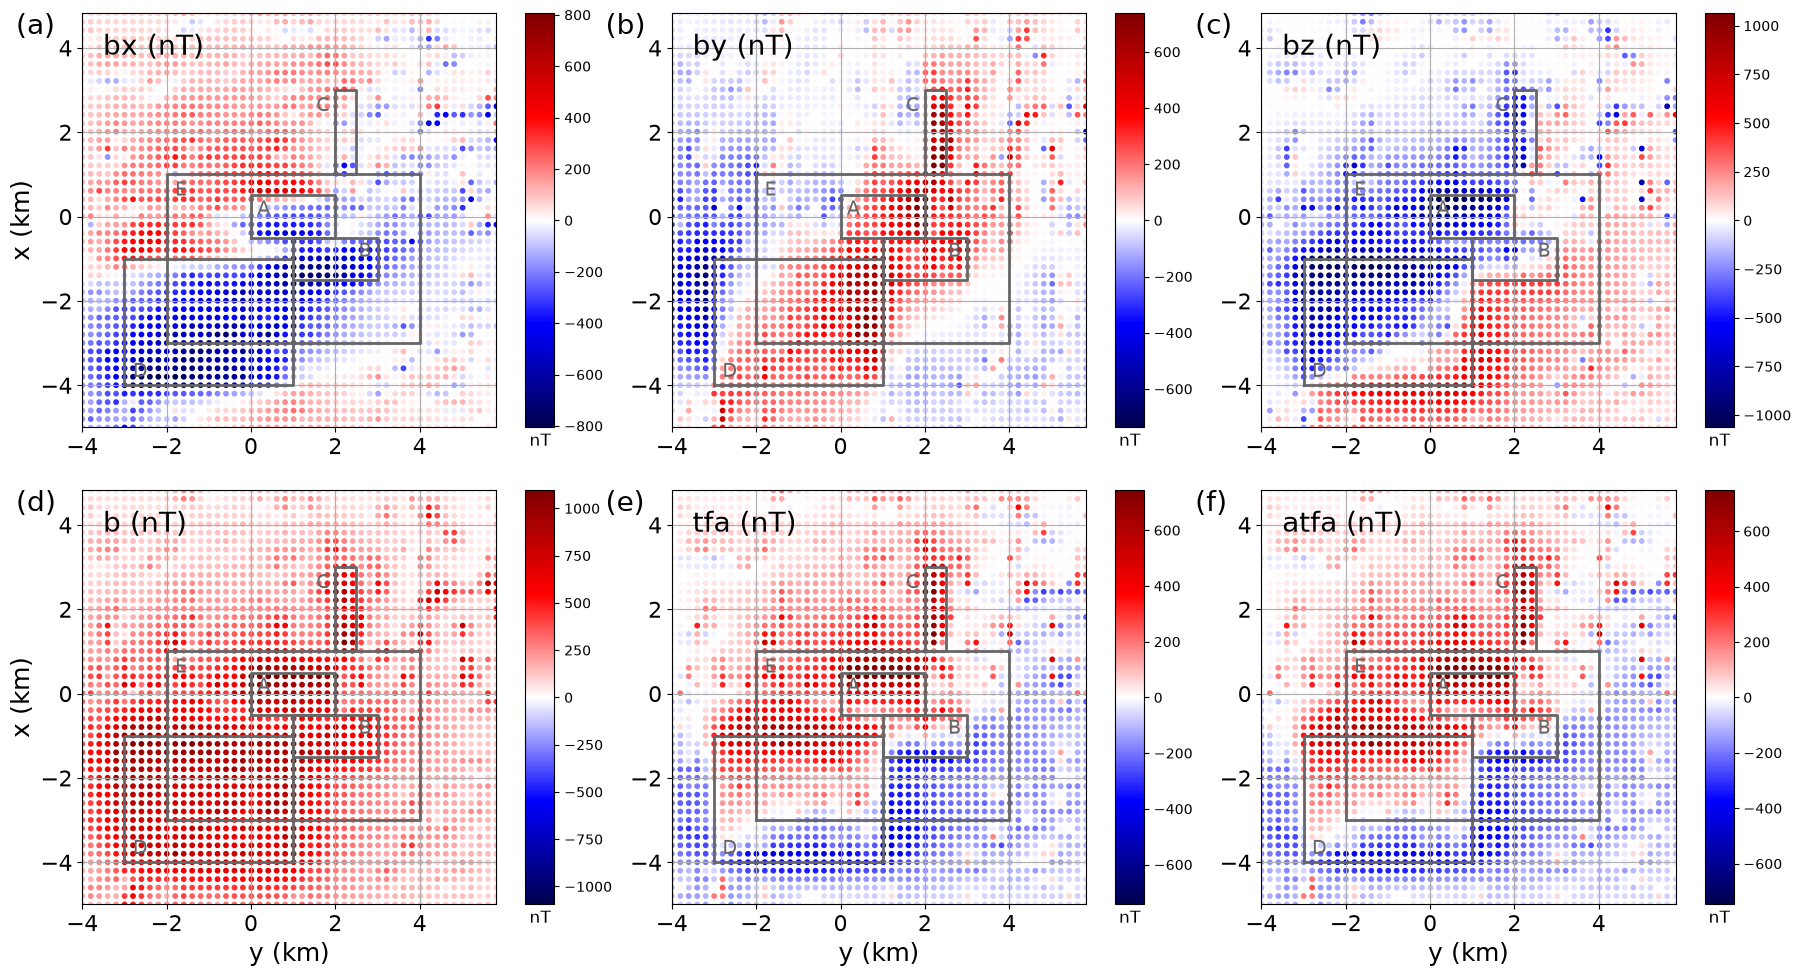

In [54]:
fig = plt.figure(layout= 'tight', figsize=(18,10))
mosaic = fig.subplot_mosaic('''
                            abc
                            def
                            ''')
# tensor components
for (element, field, title, label, ranges_field) in zip(
    mosaic_elements, crustal_field.keys(), titles, labels, ranges
):
    ax = mosaic[element]
    ax.axis('scaled')
    im = ax.scatter(
        x = data_points['coordinates']['y']*0.001, 
        y = data_points['coordinates']['x']*0.001, 
        s = 10,
        c = crustal_field[field],
        cmap='seismic', vmin=-ranges_field, vmax=ranges_field
    )
    ax_divider = make_axes_locatable(ax)
    cax = ax_divider.append_axes("right", size="7%", pad="7%")
    cb = fig.colorbar(im, cax=cax, orientation='vertical')
    cb.ax.tick_params(labelsize=10, top=False, bottom=True, labeltop=False, labelbottom=True)
    cb.ax.set_xlabel('nT', fontsize=12, loc='center')
    ax.set_ylim(0.001*data_points['area'][0], 0.001*data_points['area'][1])
    ax.set_xlim(0.001*data_points['area'][2], 0.001*data_points['area'][3])
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid()
    ax.annotate(label, xy=(-0.16, 0.95), xycoords='axes fraction', fontsize=20)
    ax.annotate(title, xy=(0.05, 0.90), xycoords='axes fraction', fontsize=20)
    plf.model_boundaries(
        ax,
        model=model_cut(model['prisms'], pmin=0, pmax=4),
        color=color,
        style='-',
        width='2'
    )
    ax.annotate(text='A', xy=(0.15, 0.05), fontsize=14, color=color)
    ax.annotate(text='B', xy=(2.55, -0.95), fontsize=14, color=color)
    ax.annotate(text='C', xy=(1.55, 2.50), fontsize=14, color=color)
    ax.annotate(text='D', xy=(-2.80, -3.80), fontsize=14, color=color)
    ax.annotate(text='E', xy=(-1.80, 0.50), fontsize=14, color=color)

for element in ['a','d']:
    mosaic[element].set_ylabel('x (km)', fontsize=18)
for element in ['d','e', 'f']:
    mosaic[element].set_xlabel('y (km)', fontsize=18)

plt.show()

In [55]:
titles = ['tfa', 'atfa', 'atfa - tfa']
labels = ['(a)', '(b)', '(c)']

In [56]:
ranges_tfa = np.max(np.abs(crustal_field['tfa']))
ranges = [
    ranges_tfa, ranges_tfa, 
    np.max(np.abs(crustal_field['atfa'] - crustal_field['tfa']))
]

In [57]:
mosaic_elements = ['a', 'b', 'c']

In [58]:
color = 3*(0.4,)

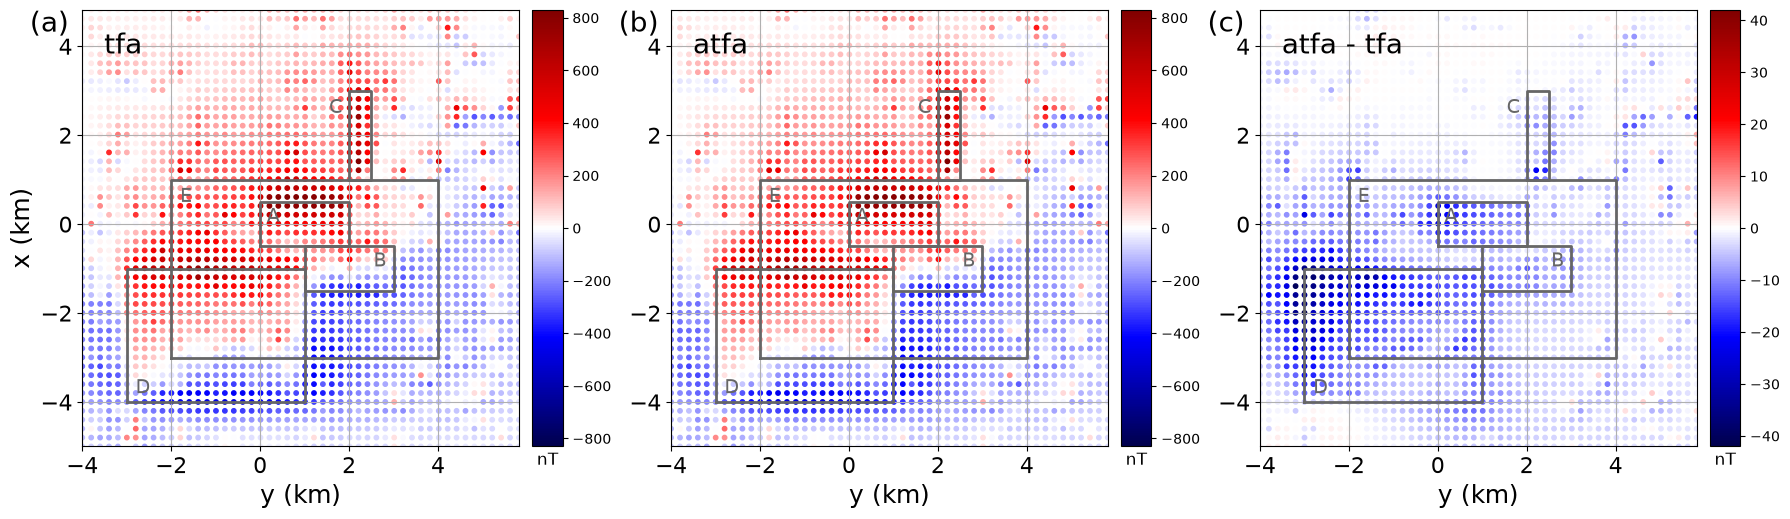

In [59]:
fig = plt.figure(layout= 'tight', figsize=(18,7))
mosaic = fig.subplot_mosaic('''
                            abc
                            ''')
# tensor components
for (element, field, title, label, ranges_field) in zip(
    mosaic_elements, 
    [crustal_field['tfa'], crustal_field['atfa'], crustal_field['atfa'] - crustal_field['tfa']], 
    titles, labels, ranges
):
    ax = mosaic[element]
    ax.axis('scaled')
    im = ax.scatter(
        x = data_points['coordinates']['y']*0.001,
        y = data_points['coordinates']['x']*0.001,
        s = 10,
        c = field,
        cmap='seismic', vmin=-ranges_field, vmax=ranges_field
    )
    ax_divider = make_axes_locatable(ax)
    cax = ax_divider.append_axes("right", size="7%", pad="3%")
    cb = fig.colorbar(im, cax=cax, orientation='vertical')
    cb.ax.tick_params(labelsize=10, top=False, bottom=True, labeltop=False, labelbottom=True)
    cb.ax.set_xlabel('nT', fontsize=12, loc='center')
    ax.set_ylim(0.001*data_points['area'][0], 0.001*data_points['area'][1])
    ax.set_xlim(0.001*data_points['area'][2], 0.001*data_points['area'][3])
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid()
    ax.annotate(label, xy=(-0.12, 0.95), xycoords='axes fraction', fontsize=20)
    ax.annotate(title, xy=(0.05, 0.90), xycoords='axes fraction', fontsize=20)
    plf.model_boundaries(
        ax,
        model=model_cut(model['prisms'], pmin=0, pmax=4),
        color=color,
        style='-',
        width='2'
    )
    ax.annotate(text='A', xy=(0.15, 0.05), fontsize=14, color=color)
    ax.annotate(text='B', xy=(2.55, -0.95), fontsize=14, color=color)
    ax.annotate(text='C', xy=(1.55, 2.50), fontsize=14, color=color)
    ax.annotate(text='D', xy=(-2.80, -3.80), fontsize=14, color=color)
    ax.annotate(text='E', xy=(-1.80, 0.50), fontsize=14, color=color)

for element in ['a']:
    mosaic[element].set_ylabel('x (km)', fontsize=18)
for element in ['a','b','c']:
    mosaic[element].set_xlabel('y (km)', fontsize=18)

plt.show()

In [60]:
print("Average values of")
for field in crustal_field.keys():
    print(f"{field:>6s}: {np.mean(crustal_field[field]):>7.3f} nT")

Average values of
     x: -42.948 nT
     y:  49.316 nT
     z: -63.166 nT
     b: 369.460 nT
  atfa:  38.087 nT
   tfa:  43.186 nT


### Regional field

In [61]:
regional_field = (
    300.0 
    -4e-3*(data_points['coordinates']['x']-xc) 
    +8e-3*(data_points['coordinates']['y']-yc) 
    +1e-6*(data_points['coordinates']['x']-xc)*(data_points['coordinates']['x']-xc) 
    -5e-6*(data_points['coordinates']['y']-yc)*(data_points['coordinates']['y']-yc)
)

In [62]:
titles = ['regional', 'tfa', 'tfa + regional']
labels = ['(a)', '(b)', '(c)']

In [63]:
ranges_tfa_regional = np.max(np.abs(crustal_field['tfa'] + regional_field))
ranges_tfa = np.max(np.abs(crustal_field['tfa']))
ranges = [
    [np.min(regional_field), np.max(regional_field)],
    [-ranges_tfa_regional, ranges_tfa_regional], 
    [-ranges_tfa_regional, ranges_tfa_regional]
]

In [64]:
cmaps = ['viridis', 'seismic', 'seismic']

In [65]:
mosaic_elements = ['a', 'b', 'c']

In [66]:
color = 3*(0.4,)

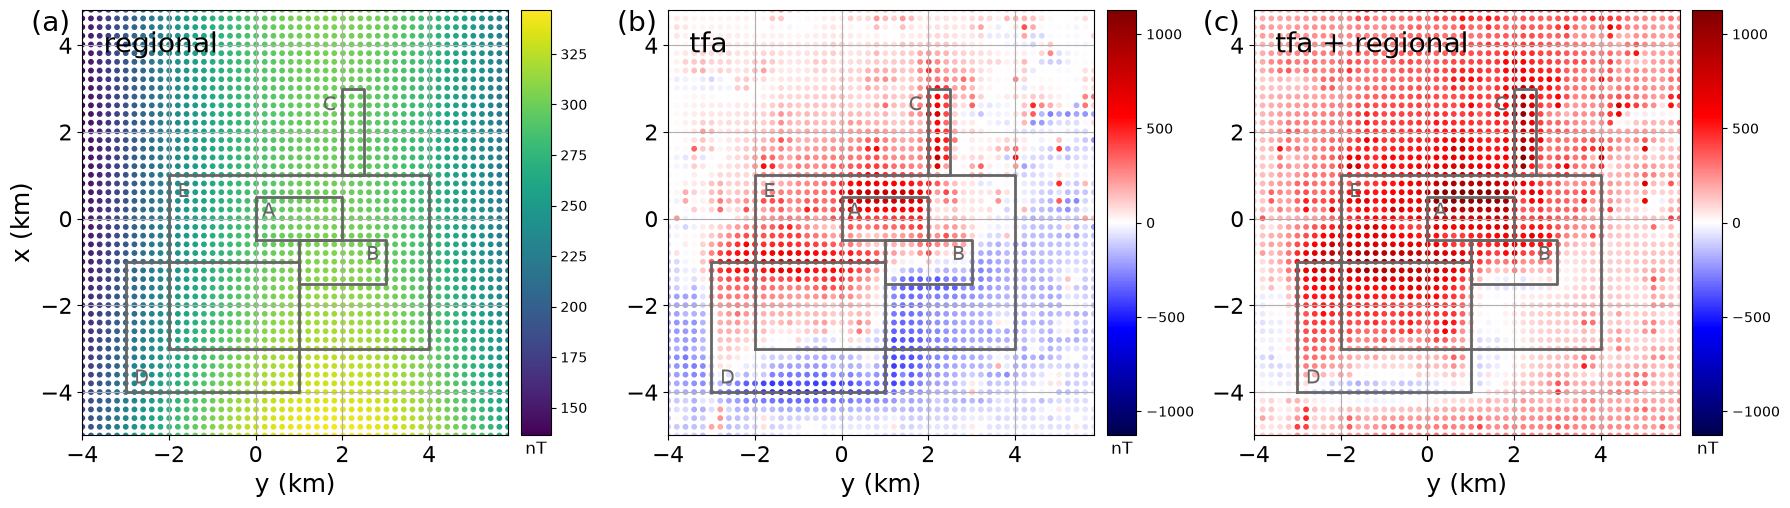

In [67]:
fig = plt.figure(layout= 'tight', figsize=(18,7))
mosaic = fig.subplot_mosaic('''
                            abc
                            ''')
# tensor components
for (element, field, title, label, ranges_field, cmap) in zip(
    mosaic_elements, 
    [regional_field, crustal_field['tfa'], crustal_field['tfa'] + regional_field], 
    titles, labels, ranges, cmaps
):
    ax = mosaic[element]
    ax.axis('scaled')
    im = ax.scatter(
        x = data_points['coordinates']['y']*0.001, 
        y = data_points['coordinates']['x']*0.001, 
        s = 10,
        c = field,
        cmap=cmap, vmin=ranges_field[0], vmax=ranges_field[1]
    )
    ax_divider = make_axes_locatable(ax)
    cax = ax_divider.append_axes("right", size="7%", pad="3%")
    cb = fig.colorbar(im, cax=cax, orientation='vertical')
    cb.ax.tick_params(labelsize=10, top=False, bottom=True, labeltop=False, labelbottom=True)
    cb.ax.set_xlabel('nT', fontsize=12, loc='center')
    ax.set_ylim(0.001*data_points['area'][0], 0.001*data_points['area'][1])
    ax.set_xlim(0.001*data_points['area'][2], 0.001*data_points['area'][3])
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid()
    ax.annotate(label, xy=(-0.12, 0.95), xycoords='axes fraction', fontsize=20)
    ax.annotate(title, xy=(0.05, 0.90), xycoords='axes fraction', fontsize=20)
    plf.model_boundaries(
        ax,
        model=model_cut(model['prisms'], pmin=0, pmax=4),
        color=color,
        style='-',
        width='2'
    )
    ax.annotate(text='A', xy=(0.15, 0.05), fontsize=14, color=color)
    ax.annotate(text='B', xy=(2.55, -0.95), fontsize=14, color=color)
    ax.annotate(text='C', xy=(1.55, 2.50), fontsize=14, color=color)
    ax.annotate(text='D', xy=(-2.80, -3.80), fontsize=14, color=color)
    ax.annotate(text='E', xy=(-1.80, 0.50), fontsize=14, color=color)

for element in ['a']:
    mosaic[element].set_ylabel('x (km)', fontsize=18)
for element in ['a','b','c']:
    mosaic[element].set_xlabel('y (km)', fontsize=18)

plt.show()

### Estimate the regional field

In [68]:
G3D = fc.G_2D(
    P=np.vstack([
        data_points['coordinates']['x'], 
        data_points['coordinates']['y'],
    ]).T, 
    t=0.0, 
    P_interp=None
)

In [69]:
# Least-squares solution
coeffs = np.linalg.solve(G3D.T@G3D, G3D.T@(crustal_field['tfa']+regional_field))

In [70]:
# Estimated regional field from least-squares solution
estimated_regional = G3D@coeffs

In [75]:
iteracoes = 3

for i in range(iteracoes):
    r = (crustal_field['tfa']+regional_field) - estimated_regional
    s = np.median(r)
    W = np.diag(1./np.abs(r + 1e-7))
    W = G3D.T@W
    coeffs[:] = np.linalg.solve(W@G3D, W@(crustal_field['tfa']+regional_field))
    estimated_regional[:] = G3D@coeffs

In [71]:
titles = ['regional', 'tfa', 'tfa + regional']
labels = ['(a)', '(b)', '(c)']

In [72]:
cmaps = ['viridis', 'viridis', 'viridis']

In [73]:
mosaic_elements = ['a', 'b', 'c']

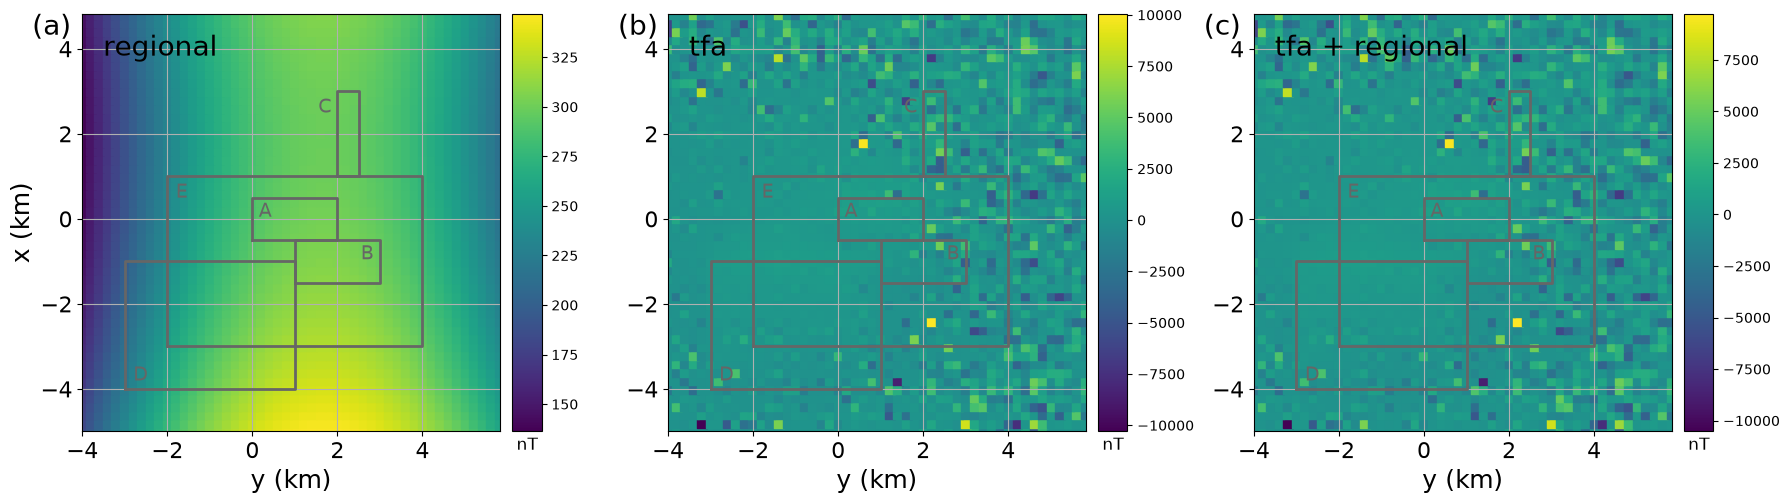

In [76]:
fig = plt.figure(layout= 'tight', figsize=(18,7))
mosaic = fig.subplot_mosaic('''
                            abc
                            ''')
# tensor components
for (element, field, title, label, ranges_field, cmap) in zip(
    mosaic_elements, 
    [regional_field, estimated_regional, estimated_regional - regional_field], 
    titles, labels, ranges, cmaps
):
    ax = mosaic[element]
    ax.axis('scaled')
    im = ax.scatter(
        x = data_points['coordinates']['y']*0.001, 
        y = data_points['coordinates']['x']*0.001, 
        s = 50, marker = 's',
        c = field,
        cmap=cmap, 
        # cmap='seismic',
        # vmin=np.min(regional_field), vmax=np.max(regional_field)
        vmin=np.min(field), vmax=np.max(field)
        # vmin=-np.max(np.abs(field)), vmax=np.max(np.abs(field))
    )
    ax_divider = make_axes_locatable(ax)
    cax = ax_divider.append_axes("right", size="7%", pad="3%")
    cb = fig.colorbar(im, cax=cax, orientation='vertical')
    cb.ax.tick_params(labelsize=10, top=False, bottom=True, labeltop=False, labelbottom=True)
    cb.ax.set_xlabel('nT', fontsize=12, loc='center')
    ax.set_ylim(0.001*data_points['area'][0], 0.001*data_points['area'][1])
    ax.set_xlim(0.001*data_points['area'][2], 0.001*data_points['area'][3])
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid()
    ax.annotate(label, xy=(-0.12, 0.95), xycoords='axes fraction', fontsize=20)
    ax.annotate(title, xy=(0.05, 0.90), xycoords='axes fraction', fontsize=20)
    plf.model_boundaries(
        ax,
        model=model_cut(model['prisms'], pmin=0, pmax=4),
        color=color,
        style='-',
        width='2'
    )
    ax.annotate(text='A', xy=(0.15, 0.05), fontsize=14, color=color)
    ax.annotate(text='B', xy=(2.55, -0.95), fontsize=14, color=color)
    ax.annotate(text='C', xy=(1.55, 2.50), fontsize=14, color=color)
    ax.annotate(text='D', xy=(-2.80, -3.80), fontsize=14, color=color)
    ax.annotate(text='E', xy=(-1.80, 0.50), fontsize=14, color=color)

for element in ['a']:
    mosaic[element].set_ylabel('x (km)', fontsize=18)
for element in ['a','b','c']:
    mosaic[element].set_xlabel('y (km)', fontsize=18)

plt.show()

### Select regional data

In [ ]:
plt.close('all')

figsize=10
fig, ax = plt.subplots(figsize=(figsize,0.8*figsize))
ax.axis('scaled')

ax.set_title('click Esc to finish and close the window', fontsize=16)

im = ax.scatter(
    x = data_points['coordinates']['y']*0.001, 
    y = data_points['coordinates']['x']*0.001, 
    s = 10,
    c = crustal_field['tfa']+regional_field,
    cmap='seismic', vmin=-ranges_tfa_regional, vmax=ranges_tfa_regional
)
ax_divider = make_axes_locatable(ax)
cax = ax_divider.append_axes("right", size="7%", pad="3%")
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.ax.tick_params(labelsize=10, top=False, bottom=True, labeltop=False, labelbottom=True)
cb.ax.set_xlabel('nT', fontsize=12, loc='center')
ax.set_ylim(0.001*data_points['area'][0], 0.001*data_points['area'][1])
ax.set_xlim(0.001*data_points['area'][2], 0.001*data_points['area'][3])
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid()

ax.set_ylabel('x (km)', fontsize=18)
ax.set_xlabel('y (km)', fontsize=18)

boundary_points = fig.ginput(n=-1, timeout=-1, show_clicks=True)

plt.show()

In [ ]:
regional_field.shape

In [ ]:
boundary_points = np.array(boundary_points)[:,::-1]*1e3

In [ ]:
Boundary = Polygon(shell=boundary_points[:,::-1])

In [ ]:
mask = np.empty(shape=data_points['shape'], dtype=bool)

In [ ]:
for i in range(data_points['shape'][0]):
    for j in range(data_points['shape'][1]):
        mask[i,j] = Boundary.contains(Point(Y[i,j], X[i,j]))

In [ ]:
plt.close('all')

figsize=10
fig, ax = plt.subplots(figsize=(figsize,0.8*figsize))
ax.axis('scaled')

im = ax.scatter(
    x=1e-3*Y[~mask],
    y=1e-3*X[~mask],
    s=100, marker='s', 
    c=data_structures.grid_xy_full_flatten_to_matrix(
        data=crustal_field['tfa']+regional_field,
        grid_orientation=main_field['grid_orientation'],
        shape=data_points['shape']
    )[~mask],
    cmap='seismic', vmin=-ranges_tfa_regional, vmax=ranges_tfa_regional
)
ax_divider = make_axes_locatable(ax)
cax = ax_divider.append_axes("right", size="7%", pad="3%")
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.ax.tick_params(labelsize=10, top=False, bottom=True, labeltop=False, labelbottom=True)
cb.ax.set_xlabel('nT', fontsize=12, loc='center')
ax.set_ylim(0.001*data_points['area'][0], 0.001*data_points['area'][1])
ax.set_xlim(0.001*data_points['area'][2], 0.001*data_points['area'][3])
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid()

ax.set_ylabel('x (km)', fontsize=18)
ax.set_xlabel('y (km)', fontsize=18)

plt.show()